In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor

# Metrics (Regression + Classification for your specific requirements)
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, f1_score, confusion_matrix, classification_report

import joblib # For saving the model later

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mosapabdelghany/medical-insurance-cost-dataset")

100%|██████████| 16.0k/16.0k [00:00<00:00, 7.98MB/s]

Extracting files...


In [4]:
import os

# 1. Locate the CSV file in the downloaded path
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# 2. Load into DataFrame
df = pd.read_csv(full_path)

# 3. Initial Inspection
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


/tmp/ipykernel_4227/89270406.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


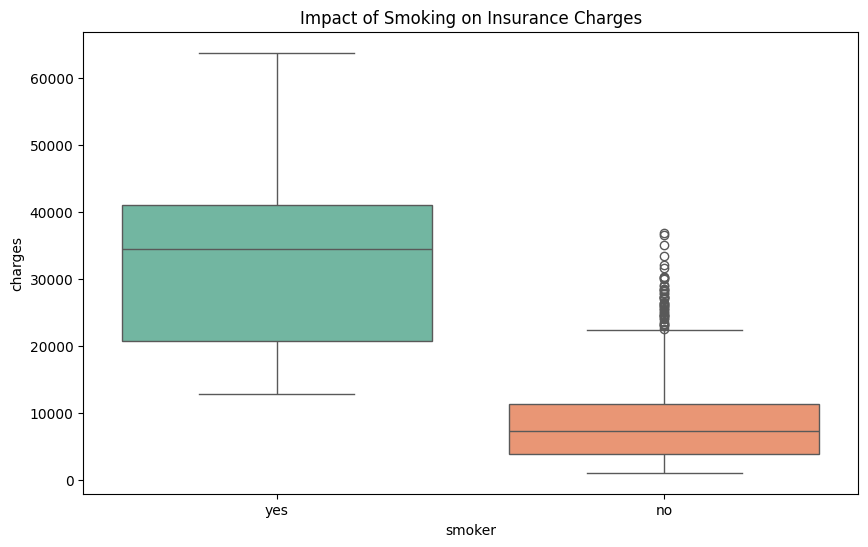

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Impact of Smoking on Insurance Charges')
plt.show()

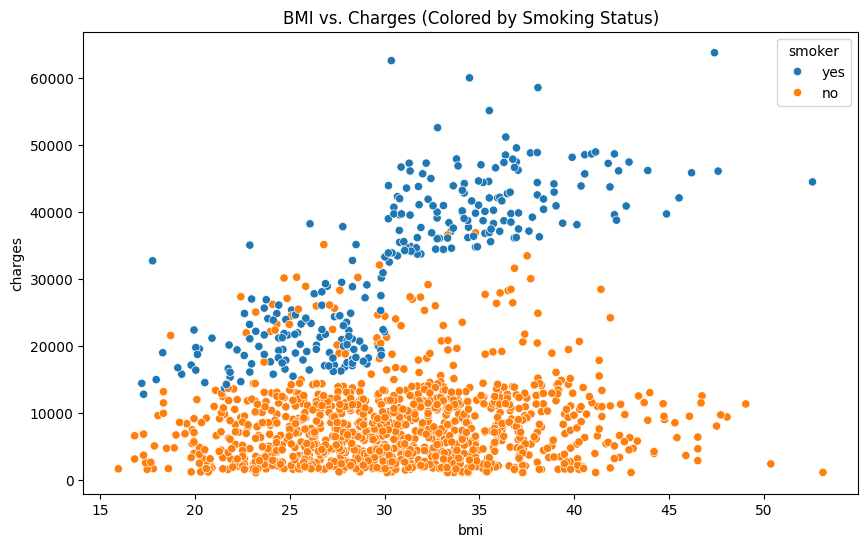

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('BMI vs. Charges (Colored by Smoking Status)')
plt.show()

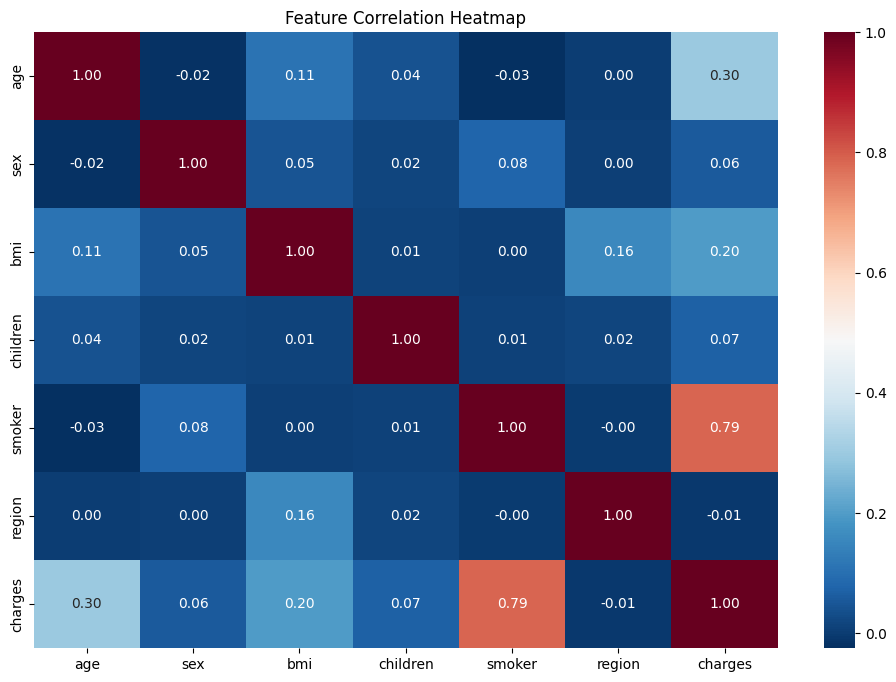

In [7]:
# We temporarily encode just for the heatmap
temp_df = df.copy()
for col in ['sex', 'smoker', 'region']:
    temp_df[col] = LabelEncoder().fit_transform(temp_df[col])

plt.figure(figsize=(12, 8))
sns.heatmap(temp_df.corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [8]:
# Check for missing values and data types
print(df.info())

# Statistical summary of numerical columns
print(df.describe())

# Check for null values specifically
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max

In [ ]:
# --- PHASE 3: PREPROCESSING ---

# 1. Encoding Categorical Variables
# Binary encoding for gender (0/1)
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

In [ ]:
df.head()

In [ ]:
# Binary encoding for smoker (0/1)
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [ ]:
df.head()

In [ ]:
# 2. One-Hot Encoding ALL Regions (Presentable version)
region_dummies = pd.get_dummies(df['region'], prefix='region', drop_first=False)
df = pd.concat([df, region_dummies], axis=1)

In [ ]:
df.head()

In [ ]:
# 3. Define the Clean Feature Set (X) and Target (y)
# We drop the original string columns and 'charges'
features = ['age', 'bmi', 'children', 'sex', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
X = df[features]
y = df['charges']

In [ ]:
# 4. Train-Test Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 5. Feature Scaling
scaler = StandardScaler()
num_cols = ['age', 'bmi', 'children']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
# 5. Define Classification Bins (For Phase 5 Metrics)
# Based on your data distribution (50th percentile is ~9.3k, 75th is ~16.6k)
def categorize_charges(val):
    if val < 10000: return 0   # Low Cost
    elif val < 30000: return 1  # Medium Cost
    else: return 2             # High Cost (Risk)

# Create the "Ground Truth" classes for our final evaluation
y_test_actual_classes = y_test.apply(categorize_charges)

In [ ]:
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")